# Boston Housing
## NumPy + Pandas + Sklearn  
### Анализ цен на жильё в Бостоне  

**Автор:** Сюльжин Савелий



В данной работе проводится анализ датасета Boston Housing.  
Цель — выполнить первичный анализ данных, предобработку, визуализацию, построить модель линейной регрессии, реализовать её вручную и выполнить кластеризацию.

## Столбцы Boston Housing

- **CRIM** — уровень преступности  
- **ZN** — доля районов с большими домами  
- **INDUS** — доля промышленных зон  
- **CHAS** — рядом ли река (0/1)  
- **NOX** — загрязнение воздуха  
- **RM** — среднее число комнат 
- **AGE** — доля старых домов  
- **DIS** — расстояние до рабочих центров  
- **RAD** — доступ к шоссе  
- **TAX** — налог на недвижимость  
- **PTRATIO** — ученики на учителя 
- **B** — демографический показатель  
- **LSTAT** — доля малообеспеченных 
- **MEDV** — цена жилья 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

## Загрузка данных

In [22]:
df = pd.read_csv("BostonHousing.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


Датасет содержит 506 наблюдений и 13 признаков.  
Целевая переменная — `MEDV` (стоимость жилья).

##  1. Первичный анализ

In [23]:
print("Размерность:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

Размерность: (506, 14)

Типы данных:
CRIM         float64
ZN           float64
INDUS        float64
CHAS           int64
NOX          float64
RM           float64
AGE          float64
DIS          float64
RAD            int64
TAX            int64
PTRATIO      float64
LSTAT        float64
MEDV         float64
CAT. MEDV      int64
dtype: object


In [24]:
print("Пропуски:")
print(df.isnull().sum())

Пропуски:
CRIM         0
ZN           0
INDUS        0
CHAS         0
NOX          0
RM           0
AGE          0
DIS          0
RAD          0
TAX          0
PTRATIO      0
LSTAT        0
MEDV         0
CAT. MEDV    0
dtype: int64


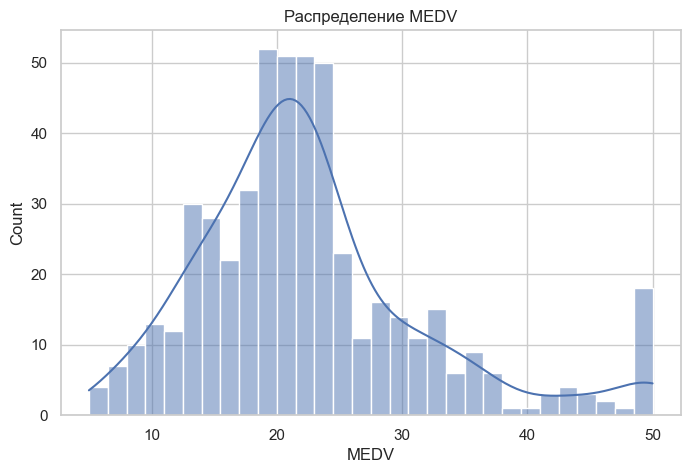

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=30, kde=True)
plt.title("Распределение MEDV")
plt.show()

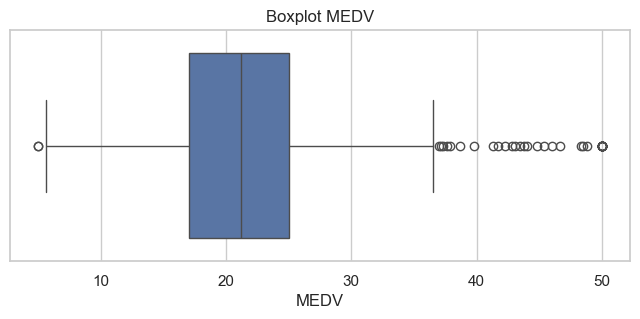

In [26]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["MEDV"])
plt.title("Boxplot MEDV")
plt.show()

In [27]:
corr = df.corr(numeric_only=True)["MEDV"].sort_values(ascending=False)
corr

MEDV         1.000000
CAT. MEDV    0.789789
RM           0.695360
ZN           0.360445
DIS          0.249929
CHAS         0.175260
AGE         -0.376955
RAD         -0.381626
CRIM        -0.388305
NOX         -0.427321
TAX         -0.468536
INDUS       -0.483725
PTRATIO     -0.507787
LSTAT       -0.737663
Name: MEDV, dtype: float64

### Вывод
Пропусков нет.  
Наиболее сильные признаки: RM (положительная связь), LSTAT (отрицательная).

##  2. Предобработка

In [28]:
df["is_high_value"] = (df["MEDV"] > 30).astype(int)

новый столбец, если >30 =1, else 0

In [29]:
z = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
df_clean = df[(z < 3).all(axis=1)].copy()

print(df.shape, "→", df_clean.shape)

(506, 15) → (436, 15)


stats.zscore(...) - насколько значение далеко от среднего

оставляем, если < 3 стандартных отклонений

In [30]:
features = df_clean.drop(columns=["MEDV", "is_high_value"])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

масштабирование

ф-ла: (x - среднее) / стандартное отклонение

medv дропаем, тк это цель и масштабить нельзя

### Вывод
Удалены выбросы и выполнена стандартизация признаков.

##  3. Визуализация

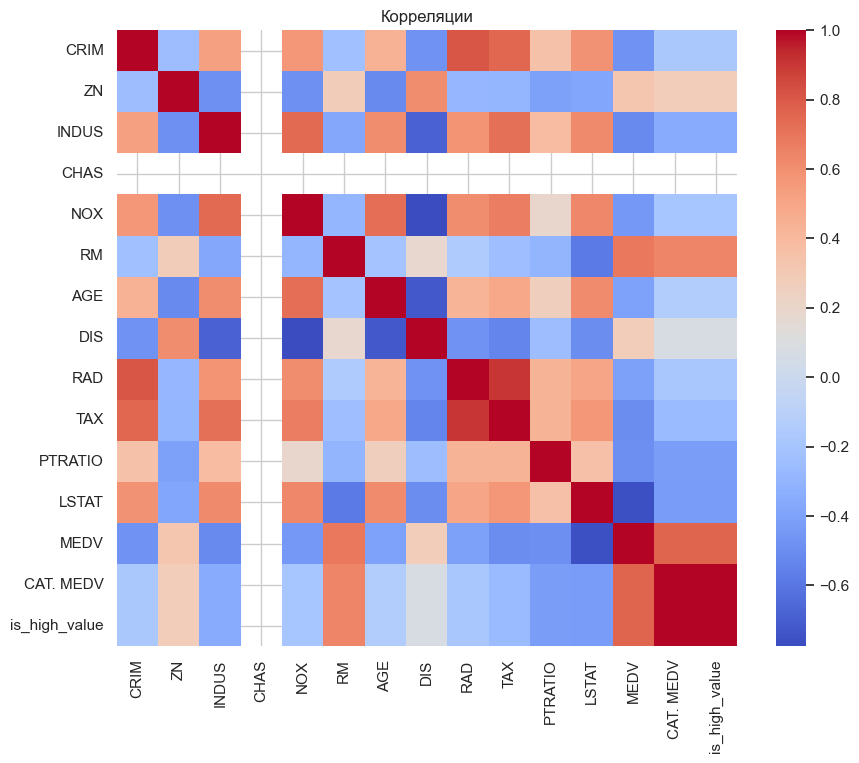

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm")
plt.title("Корреляции")
plt.show()

тепловая карта корреляций

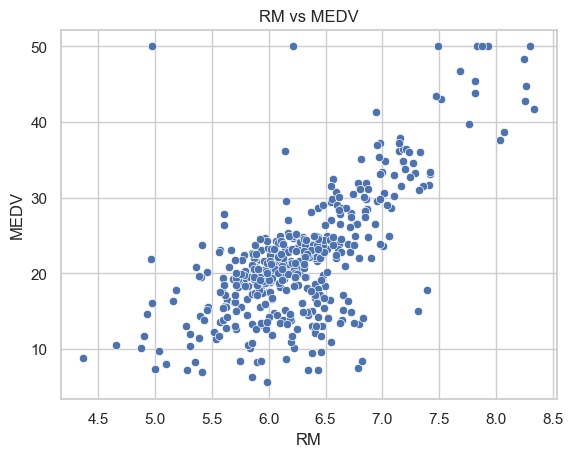

In [32]:
sns.scatterplot(x=df_clean["RM"], y=df_clean["MEDV"])
plt.title("RM vs MEDV")
plt.show()

scatter plot. при увеличении числа комнат стоимость жилья возрастает.разброс точек говорит о влиянии других факторов.

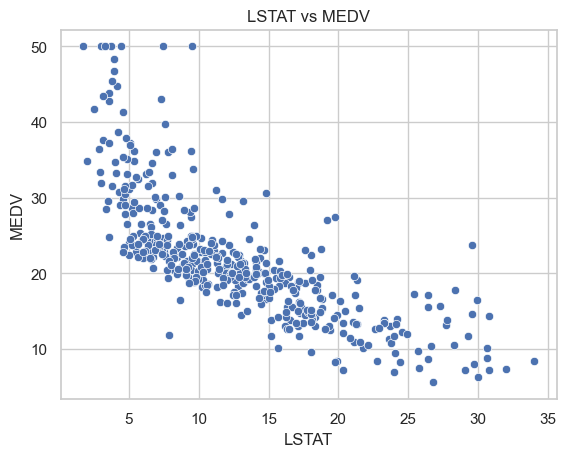

In [33]:
sns.scatterplot(x=df_clean["LSTAT"], y=df_clean["MEDV"])
plt.title("LSTAT vs MEDV")
plt.show()

чем больше LSTAT (бедные), тем ниже цена

### Вывод
RM увеличивает цену, LSTAT уменьшает.

##  4. Линейная регрессия

In [34]:
X = df_clean[["RM", "LSTAT", "PTRATIO"]]
y = df_clean["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X — входные данные (признаки)
y — то, что предсказываем (цена)

делим данные:
80% → обучение
20% → проверка

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Модель обучается находить линейную зависимость между признаками и ценой жилья.

MEDV = b0 + b1*RM + b2*LSTAT + b3*PTRATIO

In [36]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.748208519447618
MAE: 2.470507938237249
RMSE: 3.7693637301915124


модель объясняет 74% ценообразования, ошибка +- 2,5k$, rmse - большая ошибка

### Вывод
Модель показывает хорошее качество. RM увеличивает цену, LSTAT снижает.

## Задание 5. NumPy-регрессия

In [37]:
X_m = df_clean[["RM","LSTAT","PTRATIO"]].values
y_m = df_clean["MEDV"].values.reshape(-1,1)

X_m = np.hstack([np.ones((X_m.shape[0],1)), X_m]) #добавляем единичный столбец для учета b0 (y = b0 + b1*x1 + b2*x2)

beta = np.linalg.inv(X_m.T @ X_m) @ X_m.T @ y_m
beta

array([[15.26303606],
       [ 4.79491712],
       [-0.57760822],
       [-0.86959106]])

Данные переводятся в формат NumPy для выполнения матричных операций

β = (XᵀX)⁻¹ Xᵀy

15.26   → b0 (свободный член) или базовая цена

 4.79   → RM +1 комната цена вверх на

-0.57   → LSTAT +1% бедных цена вниз на

-0.87   → PTRATIO хуже школы

##  6. Кластеризация

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean["cluster"] = kmeans.fit_predict(df_clean[["CRIM","NOX","DIS"]])

случайно выбирает центры

относит точки к ближайшему центру

пересчитывает центры

повторяет

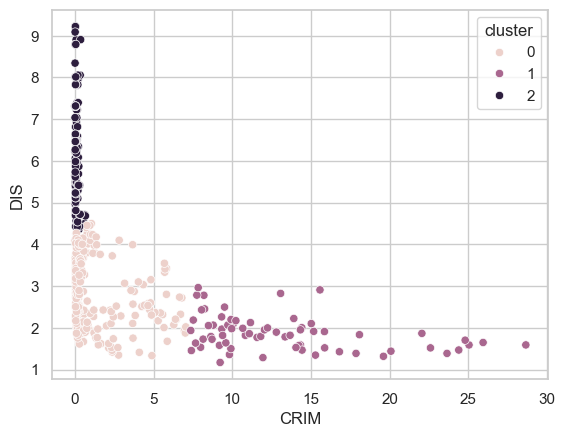

In [39]:
sns.scatterplot(x=df_clean["CRIM"], y=df_clean["DIS"], hue=df_clean["cluster"])
plt.show()

In [40]:
df_clean.groupby("cluster")["MEDV"].mean()

cluster
0    22.885463
1    13.422059
2    24.265248
Name: MEDV, dtype: float64

### Вывод
Кластеры отличаются по средней цене жилья.

## Общий вывод

Проведен полный анализ данных Boston Housing.  
Наиболее важные признаки — RM и LSTAT.  
Линейная модель показала хорошее качество.  
Более сложные модели могут улучшить результат.